In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from projectlib.encoding import Ordinal_Encoder

# Daten laden
candidate_paths = [
    Path("adult.data"),
    Path.cwd() / "adult.data",
    Path.cwd().parent / "adult.data",
    Path.cwd().parent / "data" / "adult.data",
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Die Datei adult.data wurde nicht gefunden.")

column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv(data_path, header=None, names=column_names, na_values="?", keep_default_na=False)

# 1. Whitespaces entfernen, da Strings oft fälschlicherweise " ?" statt "?" enthalten
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip()

# 2. '?' durch ein sauberes, ökonomisch interpretierbares Label ersetzen
df = df.replace("?", "Unknown")

# Kurzer Check, ob es geklappt hat:
print("fehlende Werte in workclass:", (df['workclass'] == 'Unknown').sum())

   education  education_ordinal
0  Bachelors                 13
1  Bachelors                 13
2    HS-grad                  9
3       11th                  7
4  Bachelors                 13
5    Masters                 14
6        9th                  5
7    HS-grad                  9
8    Masters                 14
9  Bachelors                 13


C:\Users\User\AppData\Local\Temp\ipykernel_21748\2878887540.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


In [32]:
from projectlib.encoding import Ordinal_Encoder

# Ordinal Encoding für education, damit die spätere Analyse eine sinnvolle Rangordnung hat
education_order = [
    "Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
    "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
    "Prof-school", "Doctorate"
]

df["education_ordinal"] = Ordinal_Encoder(
    df[["education"]].copy(),
    "education",
    categories_order=[education_order],
    starting_numbers=[1],
    step_sizes=[1],
)["education"]

print(df[["education", "education_ordinal"]].head(10))

Neue One-Hot-Spalten:
marital_status_Never-married
marital_status_Married-civ-spouse
marital_status_Divorced
marital_status_Married-spouse-absent
marital_status_Separated
marital_status_Married-AF-spouse
marital_status_Widowed
relationship_Not-in-family
relationship_Husband
relationship_Wife
relationship_Own-child
relationship_Unmarried
relationship_Other-relative
race_White
race_Black
race_Asian-Pac-Islander
race_Amer-Indian-Eskimo
race_Other
sex_Male
sex_Female
workclass_State-gov
workclass_Self-emp-not-inc
workclass_Private
workclass_Federal-gov
workclass_Local-gov
workclass_Unknown
workclass_Self-emp-inc
workclass_Without-pay
workclass_Never-worked
native_country_grouped_North-America
native_country_grouped_Latin-America
native_country_grouped_Asia
native_country_grouped_Other
native_country_grouped_Europe

Beispielzeilen nach One-Hot-Encoding:


,income,education_ordinal,marital_status_Never-married,marital_status_Married-civ-spouse,marital_status_Divorced,marital_status_Married-spouse-absent,marital_status_Separated,marital_status_Married-AF-spouse,marital_status_Widowed,relationship_Not-in-family,...,workclass_Local-gov,workclass_Unknown,workclass_Self-emp-inc,workclass_Without-pay,workclass_Never-worked,native_country_grouped_North-America,native_country_grouped_Latin-America,native_country_grouped_Asia,native_country_grouped_Other,native_country_grouped_Europe
0,<=50K,13,1,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,<=50K,13,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,<=50K,9,0,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,<=50K,7,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,<=50K,13,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


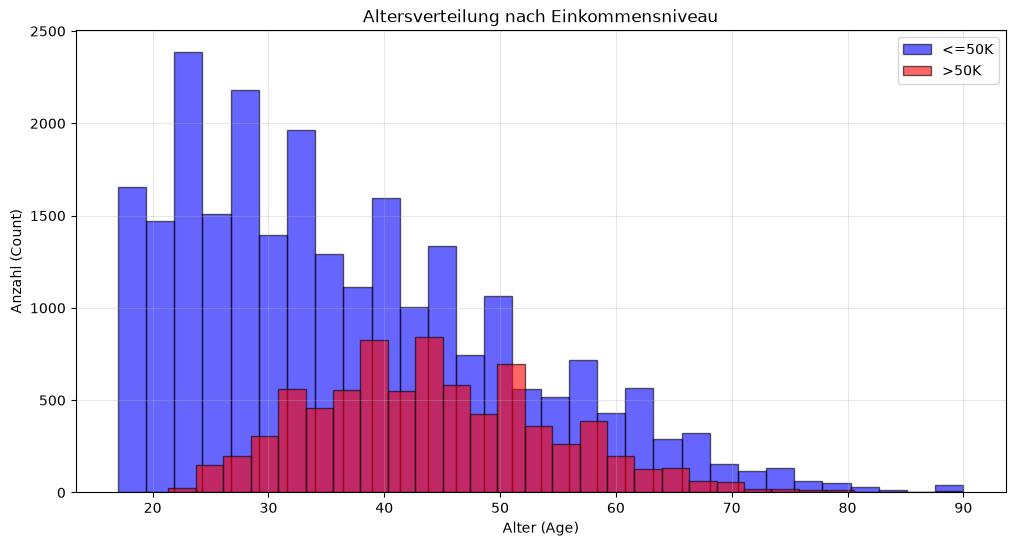

Personen mit <=50K: 24720
Personen mit >50K: 7841


In [ ]:
# Histogram: Alter vs. Einkommen
plt.figure(figsize=(12, 6))

# Separate data by income
under_50k = df[df['income'].str.strip() == '<=50K']['age']
over_50k = df[df['income'].str.strip() == '>50K']['age']

# Create histogram
plt.hist(under_50k, bins=30, alpha=0.6, label='<=50K', color='blue', edgecolor='black')
plt.hist(over_50k, bins=30, alpha=0.6, label='>50K', color='red', edgecolor='black')

plt.xlabel('Alter (Age)')
plt.ylabel('Anzahl (Count)')
plt.title('Altersverteilung nach Einkommensniveau')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print counts
print(f"Personen mit <=50K: {len(under_50k)}")
print(f"Personen mit >50K: {len(over_50k)}")

In [ ]:
# Kardinalität bestimmen
categorical_cols = df.select_dtypes(include=['object']).columns.drop('income') # ohne das Target

for col in categorical_cols:
    print(f"Feature: {col:15} | einzigartige Kategorien: {df[col].nunique()}")

Feature: workclass       | Einzigartige Kategorien: 9
Feature: education       | Einzigartige Kategorien: 16
Feature: marital_status  | Einzigartige Kategorien: 7
Feature: occupation      | Einzigartige Kategorien: 15
Feature: relationship    | Einzigartige Kategorien: 6
Feature: race            | Einzigartige Kategorien: 5
Feature: sex             | Einzigartige Kategorien: 2
Feature: native_country  | Einzigartige Kategorien: 42


C:\Users\User\AppData\Local\Temp\ipykernel_21748\3775736499.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.drop('income') # ohne das Target


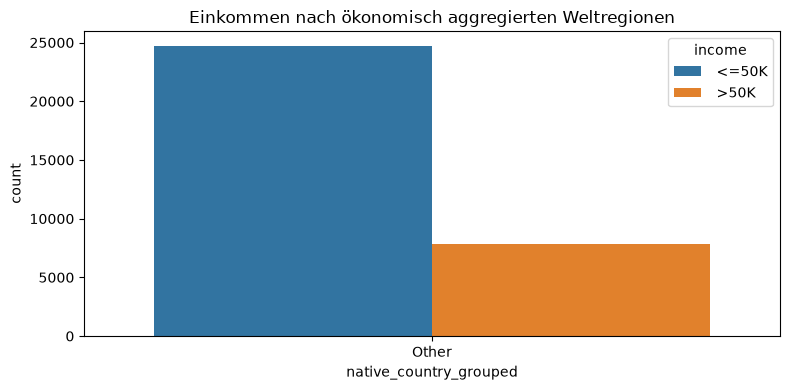

In [10]:
def aggregate_countries(country):
    if country in ['United-States', 'Canada']:
        return 'North-America'
    elif country in ['Mexico', 'Puerto-Rico', 'Cuba', 'Honduras', 'Jamaica', 'Columbia', 'Dominican-Republic', 'El-Salvador', 'Guatemala', 'Haiti', 'Nicaragua', 'Peru', 'Ecuador', 'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)']:
        return 'Latin-America'
    elif country in ['Germany', 'England', 'Italy', 'Poland', 'Portugal', 'France', 'Yugoslavia', 'Scotland', 'Greece', 'Ireland', 'Hungary', 'Holand-Netherlands']:
        return 'Europe'
    elif country in ['Philippines', 'India', 'China', 'Japan', 'Vietnam', 'Taiwan', 'Hong', 'Cambodia', 'Laos', 'Thailand', 'Iran']:
        return 'Asia'
    else:
        return 'Other'

df['native_country_grouped'] = df['native_country'].apply(aggregate_countries)

# Visualisierung des Effekts
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='native_country_grouped', hue='income', order=df['native_country_grouped'].value_counts().index)
plt.title("Einkommen nach ökonomisch aggregierten Weltregionen")
plt.tight_layout()
plt.show()

    education_ordinal     education  income_above_50k
14                  1     Preschool          0.000000
13                  2       1st-4th          0.035714
11                  3       5th-6th          0.048048
8                   4       7th-8th          0.061920
4                   5           9th          0.052529
12                  6          10th          0.066452
2                   7          11th          0.051064
15                  8          12th          0.076212
1                   9       HS-grad          0.159509
5                  10  Some-college          0.190235
7                  11     Assoc-voc          0.261216
6                  12    Assoc-acdm          0.248360
0                  13     Bachelors          0.414753
3                  14       Masters          0.556587
10                 15   Prof-school          0.734375
9                  16     Doctorate          0.740920


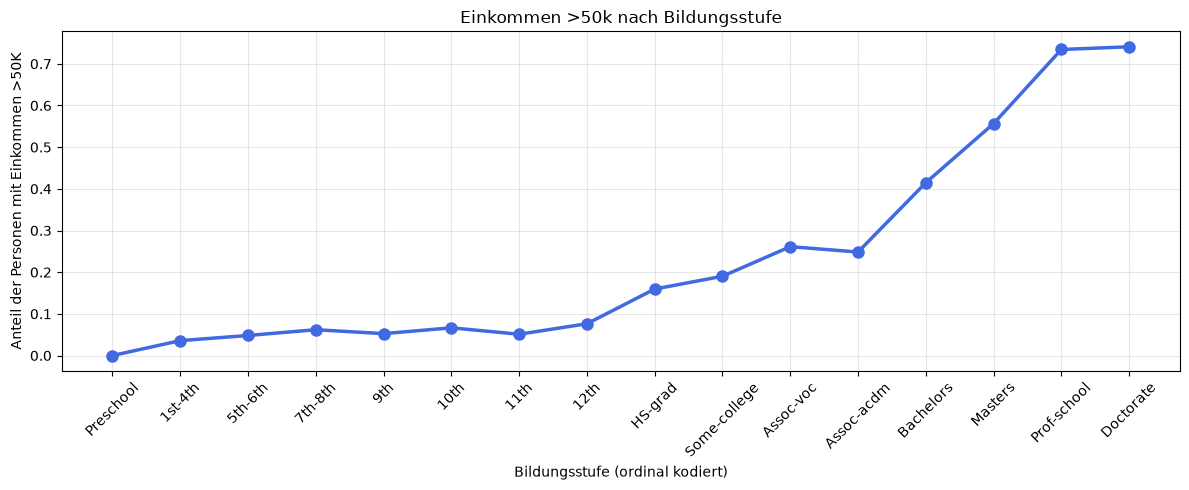

In [ ]:
# Für die Variable education ist der Ordinal Encoder geeignet, 
# da die Bildungsstufen eine natürliche, monotone Rangordnung aufweisen. 
# Dadurch kann die Reihenfolge der Bildungsniveaus erhalten bleiben, ohne die Variable in mehrere binäre Spalten zu zerlegen.

plot_df = df.copy()
plot_df['education'] = plot_df['education'].astype(str).str.strip()
plot_df['income'] = plot_df['income'].astype(str).str.strip()
plot_df['education_ordinal'] = plot_df['education_ordinal'].astype(int)
plot_df = plot_df[plot_df['education'].isin(education_order)].copy()
plot_df['income_above_50k'] = (plot_df['income'] == '>50K').astype(int)

summary = (
    plot_df.groupby(['education_ordinal', 'education'], sort=False)['income_above_50k']
    .mean()
    .reset_index()
    .sort_values('education_ordinal')
)

print(summary)

# Visualisierung als Linie mit Punkten auf Basis der ordinal kodierten Bildungsstufe

plt.figure(figsize=(12, 5))
plt.plot(summary['education_ordinal'], summary['income_above_50k'], marker='o', linestyle='-', color='royalblue', linewidth=2.5, markersize=8)
plt.xticks(summary['education_ordinal'], summary['education'], rotation=45)
plt.xlabel('Bildungsstufe (ordinal kodiert)')
plt.ylabel('Anteil der Personen mit Einkommen >50K')
plt.title('Einkommen >50k nach Bildungsstufe')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Diagnose der Einkommen-Werte
print(df['income'].head().tolist())
print('\nEinzigartige Einkommen-Werte:')
print(df['income'].astype(str).unique()[:10])

['<=50K', '<=50K', '<=50K', '<=50K', '<=50K']

Einzigartige Einkommen-Werte:
<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


In [31]:
# Diagnose: Welche Bildungsstufen sind wirklich in den Daten vorhanden?
print(df['education'].value_counts().to_string())
print('\nAnzahl der Zeilen mit education:', df['education'].notna().sum())
print('\neducation_summary:')
print(education_summary)

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51

Anzahl der Zeilen mit education: 32561

education_summary:
Series([], Name: income_above_50k, dtype: float64)


In [34]:
from projectlib.encoding import One_Hot_Encoder

# 1. Vorbereitung: aggregierte Ländergruppen erzeugen
if "native_country_grouped" not in df.columns:
    def aggregate_countries(country):
        if country in ["United-States", "Canada"]:
            return "North-America"
        elif country in ["Mexico", "Puerto-Rico", "Cuba", "Honduras", "Jamaica", "Columbia",
                         "Dominican-Republic", "El-Salvador", "Guatemala", "Haiti",
                         "Nicaragua", "Peru", "Ecuador", "Trinadad&Tobago",
                         "Outlying-US(Guam-USVI-etc)"]:
            return "Latin-America"
        elif country in ["Germany", "England", "Italy", "Poland", "Portugal", "France",
                         "Yugoslavia", "Scotland", "Greece", "Ireland", "Hungary",
                         "Holand-Netherlands"]:
            return "Europe"
        elif country in ["Philippines", "India", "China", "Japan", "Vietnam", "Taiwan",
                         "Hong", "Cambodia", "Laos", "Thailand", "Iran"]:
            return "Asia"
        else:
            return "Other"

    df["native_country_grouped"] = df["native_country"].apply(aggregate_countries)

# 2. One-Hot-Encoding der kategorialen Features
one_hot_features = ["marital_status", "relationship", "race", "sex", "workclass", "native_country_grouped"]
df_ohe = One_Hot_Encoder(df.copy(), one_hot_features, delete_old_column=True)

# 3. Ausgabe der erzeugten Features
one_hot_columns = [col for col in df_ohe.columns if any(col.startswith(f"{feature}_") for feature in one_hot_features)]
print("Erzeugte One-Hot-Features:")
print(one_hot_columns)

Erzeugte One-Hot-Features:
['marital_status_Never-married', 'marital_status_Married-civ-spouse', 'marital_status_Divorced', 'marital_status_Married-spouse-absent', 'marital_status_Separated', 'marital_status_Married-AF-spouse', 'marital_status_Widowed', 'relationship_Not-in-family', 'relationship_Husband', 'relationship_Wife', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Other-relative', 'race_White', 'race_Black', 'race_Asian-Pac-Islander', 'race_Amer-Indian-Eskimo', 'race_Other', 'sex_Male', 'sex_Female', 'workclass_State-gov', 'workclass_Self-emp-not-inc', 'workclass_Private', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Unknown', 'workclass_Self-emp-inc', 'workclass_Without-pay', 'workclass_Never-worked', 'native_country_grouped_North-America', 'native_country_grouped_Latin-America', 'native_country_grouped_Asia', 'native_country_grouped_Other', 'native_country_grouped_Europe']


In [45]:
from projectlib.encoding import Target_Encoder

# Demo: Target Encoding für workclass und occupation
# Hinweis: Für echtes Modelltraining sollte dies nur auf dem Trainingsset erfolgen.
income_target = df["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})

df_target = df.copy()
df_target["income_target"] = income_target

encoded_df = Target_Encoder(
    df_target[["workclass", "occupation", "income_target"]].copy(),
    ["workclass", "occupation"],
    "income_target"
)

print(encoded_df.head())
print("\nNeue Spalte:")
print("workclass_target")

          workclass         occupation  income_target  workclass_target  \
0         State-gov       Adm-clerical              0          0.271957   
1  Self-emp-not-inc    Exec-managerial              0          0.284927   
2           Private  Handlers-cleaners              0          0.218673   
3           Private  Handlers-cleaners              0          0.218673   
4           Private     Prof-specialty              0          0.218673   

   occupation_target  
0           0.134483  
1           0.484014  
2           0.062774  
3           0.062774  
4           0.449034  

Neue Spalte:
workclass_target


Erklärte Varianz pro Hauptkomponente:
[0.11109605 0.0662094 ]


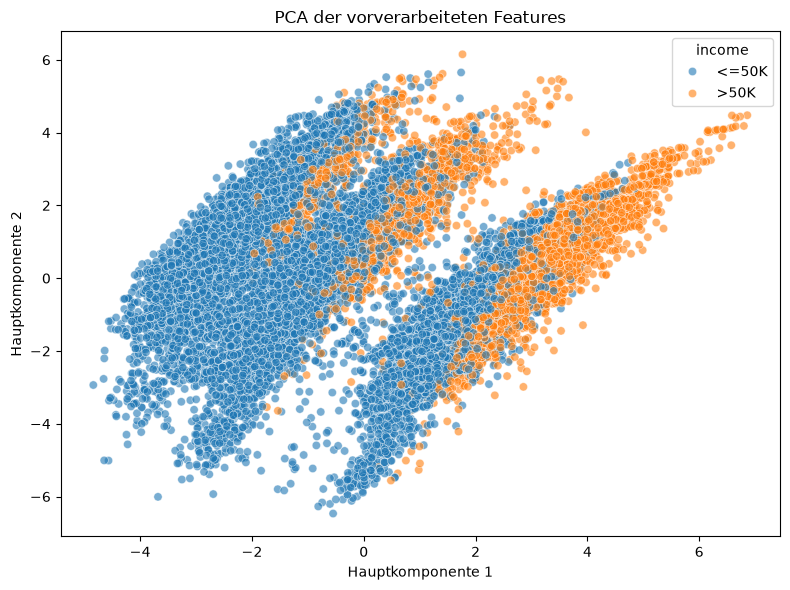

In [46]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from projectlib.encoding import One_Hot_Encoder, Ordinal_Encoder, Target_Encoder

# Zielvariable numerisch vorbereiten
income_target = df["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})

# Basisdaten kopieren und ordinal encodieren
pca_df = df.copy()
pca_df["income_target"] = income_target
pca_df["education_ordinal"] = Ordinal_Encoder(
    pca_df[["education"]].copy(),
    "education",
    categories_order=[["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
                      "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
                      "Prof-school", "Doctorate"]],
    starting_numbers=[1],
    step_sizes=[1],
)["education"]

# Originalwerte für das Target-Encoding sichern, bevor One-Hot-Encoding die alten Spalten entfernt
encoding_input = pca_df[["workclass", "occupation", "income_target"]].copy()

# One-Hot-Encoding für nominale Features
one_hot_features = ["marital_status", "relationship", "race", "sex", "workclass", "native_country_grouped"]
pca_df = One_Hot_Encoder(pca_df, one_hot_features, delete_old_column=True)

# Target-Encoding für workclass und occupation
encoded_target_df = Target_Encoder(
    encoding_input,
    ["workclass", "occupation"],
    "income_target"
)

# Vorhandene Zielspalten entfernen, falls die Zelle bereits einmal ausgeführt wurde
for col in ["workclass_target", "occupation_target"]:
    if col in pca_df.columns:
        pca_df = pca_df.drop(columns=[col])

pca_df = pd.concat(
    [pca_df.reset_index(drop=True), encoded_target_df[["workclass_target", "occupation_target"]].reset_index(drop=True)],
    axis=1,
)

# Feature-Matrix für PCA
feature_columns = [
    "age", "education_ordinal", "education_num", "capital_gain", "capital_loss",
    "hours_per_week", "income_target", "workclass_target", "occupation_target"
]
feature_columns += [
    col for col in pca_df.columns
    if col not in feature_columns
    and not col.endswith("_target")
    and any(col.startswith(f"{feature}_") for feature in one_hot_features)
]

# Nur numerische Spalten verwenden
X = pca_df[feature_columns].astype(float)

# Standardisieren
X_scaled = StandardScaler().fit_transform(X)

# PCA anwenden
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Ergebnis anzeigen
print("Erklärte Varianz pro Hauptkomponente:")
print(pca.explained_variance_ratio_)

# PCA-Daten als DataFrame speichern
pca_result = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_result["income"] = pca_df["income"].astype(str).str.strip()

# Visualisierung
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_result, x="PC1", y="PC2", hue="income", alpha=0.6)
plt.title("PCA der vorverarbeiteten Features")
plt.xlabel("Hauptkomponente 1")
plt.ylabel("Hauptkomponente 2")
plt.tight_layout()
plt.show()


In [ ]:
import sys
from pathlib import Path

root = Path.cwd()
for candidate in [root, root.parent, root.parent.parent]:
    if (candidate / "projectlib").exists():
        sys.path.insert(0, str(candidate))
        break

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from projectlib.alternativeEncoding import One_Hot_Encoder, Ordinal_Encoder, Target_Encoder_Fit, Target_Encoder_Transform

# Alternative PCA-Variante mit dem Modul alternativeEncoding.py
if "native_country_grouped" not in df.columns:
    def aggregate_countries(country):
        if country in ["United-States", "Canada"]:
            return "North-America"
        elif country in ["Mexico", "Puerto-Rico", "Cuba", "Honduras", "Jamaica", "Columbia",
                         "Dominican-Republic", "El-Salvador", "Guatemala", "Haiti",
                         "Nicaragua", "Peru", "Ecuador", "Trinadad&Tobago",
                         "Outlying-US(Guam-USVI-etc)"]:
            return "Latin-America"
        elif country in ["Germany", "England", "Italy", "Poland", "Portugal", "France",
                         "Yugoslavia", "Scotland", "Greece", "Ireland", "Hungary",
                         "Holand-Netherlands"]:
            return "Europe"
        elif country in ["Philippines", "India", "China", "Japan", "Vietnam", "Taiwan",
                         "Hong", "Cambodia", "Laos", "Thailand", "Iran"]:
            return "Asia"
        else:
            return "Other"

    df["native_country_grouped"] = df["native_country"].apply(aggregate_countries)

income_target = df["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})

pca_df = df.copy()
pca_df["income_target"] = income_target
pca_df["education_ordinal"] = Ordinal_Encoder(
    pca_df[["education"]].copy(),
    "education",
    categories_order=[["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
                      "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
                      "Prof-school", "Doctorate"]],
    starting_number=1,
    step_size=1,
)["education"]

# Target-Encoding mit dem alternativen Modul
encoding_maps = Target_Encoder_Fit(
    pca_df[["workclass", "occupation"]].copy(),
    income_target,
    ["workclass", "occupation"],
)
encoded_target_df = Target_Encoder_Transform(
    pca_df[["workclass", "occupation"]].copy(),
    ["workclass", "occupation"],
    encoding_maps,
)
pca_df = pd.concat([pca_df.drop(columns=["workclass", "occupation"]).reset_index(drop=True), encoded_target_df.reset_index(drop=True)], axis=1)

# One-Hot-Encoding für die nominalen Merkmale
one_hot_features = ["marital_status", "relationship", "race", "sex", "native_country_grouped"]
pca_df = One_Hot_Encoder(pca_df, one_hot_features, drop_first=False)

# PCA-Matrix zusammenstellen
feature_columns = [
    "age", "education_ordinal", "education_num", "capital_gain", "capital_loss",
    "hours_per_week", "income_target", "workclass_target", "occupation_target"
]
feature_columns += [
    col for col in pca_df.columns
    if col not in feature_columns and not col.endswith("_target")
    and any(col.startswith(f"{feature}_") for feature in one_hot_features)
]

X = pca_df[feature_columns].astype(float)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Erklärte Varianz pro Hauptkomponente:")
print(pca.explained_variance_ratio_)

pca_result = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_result["income"] = pca_df["income"].astype(str).str.strip()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_result, x="PC1", y="PC2", hue="income", alpha=0.6)
plt.title("PCA mit alternativeEncoding.py")
plt.xlabel("Hauptkomponente 1")
plt.ylabel("Hauptkomponente 2")
plt.tight_layout()
plt.show()